# Playing with Contextual Embeddings

In the last notebook we played with **word2vec**: every word got **one fixed vector**,
looked up from a table. That single vector had to cover *all* the meanings of a word at
once — so `mouse` collapsed to the computer sense, and "river **bank**" and "**bank**
account" were forced to share the exact same 300 numbers.

This notebook fixes that. A **contextual** model (we'll use **DistilBERT**) doesn't store
one vector per word — it **computes** a vector for each word *from the sentence it's in*.
Feed it "river bank" and the `bank` vector leans toward water; feed it "bank account" and
the same word's vector leans toward money.

Everything else is the same game as before — words become vectors, and **geometry encodes
meaning**. We'll reuse the exact same tools: cosine similarity, nearest neighbors, PCA
plots. The only new idea is that the lookup is now a **function of context**.

> We stick to **single-token words** (like `bank`, `spring`, `play`) throughout, so every
> word maps cleanly to exactly one vector. Words that get split into pieces
> (`play` + `##ing`) need a pooling rule — a wrinkle we skip on purpose to keep this as
> frictionless as the word2vec notebook.

In [1]:
# One-time install (skip if you already have these)
# %pip install transformers torch

## 1. Download the model

`transformers` ships a loader for thousands of pretrained models. We'll grab
**`distilbert-base-uncased`** — a small, fast cousin of BERT (~250 MB, 66M parameters,
**768-dimensional** vectors). It's plenty to see contextual embeddings in action.

> **Heads up:** the first run downloads the model and caches it under `~/.cache/huggingface/`.
> Subsequent runs load instantly from cache. No GPU needed — this runs fine on CPU.

In [2]:
import torch
from transformers import AutoTokenizer, AutoModel, logging

logging.set_verbosity_error()   # hide harmless load warnings (we don't use the MLM head)

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()   # inference mode: we're not training anything here

print(f"Loaded {MODEL_NAME!r}")
print("hidden size (vector dimension):", model.config.dim)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loaded 'distilbert-base-uncased'
hidden size (vector dimension): 768


## 2. A static embedding was a lookup; a contextual one is *computed*

With word2vec, getting a vector was a dictionary lookup: `model["king"]` returned the same
row every time. A contextual model is different — you hand it a **whole sentence**, it runs
a forward pass, and it hands back **one vector per token**. Change the sentence and the
vectors change.

But *where do those vectors come from?* Before we grab them, it's worth knowing what this
model was actually trained to do.

### First: what was BERT trained to do? (predict a hidden word)

DistilBERT was never trained to "produce embeddings." It was trained to **fill in the
blank** — a game called *masked language modeling*. During training, random words in a
sentence were hidden, and the model had to guess them from the words around them:

> "I deposited my paycheck at the **[MASK]** downtown."  →  *bank*

That's not a hypothetical — it's **literally the task we hand the model in Section 7**.

Here's the key move. To guess a masked word well, the model must build a rich internal
**representation of every word in the sentence** — one that has already mixed in the
surrounding context. It computes these representations layer by layer, and the final
word-prediction is read off the top.

**We don't want the prediction. We want that internal representation.** So instead of
asking "what word goes here?", we run the sentence through and read off the model's
top-layer hidden state for the word we care about — that's `last_hidden_state`. *That*
vector is our contextual embedding.

Notice the pattern: the bigram notebook's character vectors and word2vec's word vectors
both **fell out as a byproduct of a prediction task**. BERT is the same idea once more —
train a model to predict a word, and useful, context-aware vectors appear *inside* it.

word2vec played a *similar* predict-a-word game (CBOW predicts the center word from its
neighbors), but from a **shallow bag of surrounding words with order thrown away** — so it
could only ever learn **one vector per word**. Masked language modeling over a **deep
network that reads the whole sentence in order** is what lets BERT's vectors vary from one
sentence to the next.

The helper below does exactly this: give it a sentence and a target word, and it returns
*that word's* top-layer vector **in that sentence**.

In [3]:
def word_token_ids(word):
    """The wordpiece id(s) DistilBERT assigns to a bare word."""
    return tokenizer.encode(word, add_special_tokens=False)


def embed_word(sentence, word):
    """Return the contextual vector for `word` as it appears in `sentence`.

    We only support single-token words, so the mapping word -> vector is unambiguous.
    """
    ids = word_token_ids(word)
    assert len(ids) == 1, f"{word!r} is not a single token: {tokenizer.convert_ids_to_tokens(ids)}"
    target_id = ids[0]

    enc = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():                       # no training, no gradients
        out = model(**enc)
    hidden = out.last_hidden_state[0]           # (num_tokens, 768)

    input_ids = enc["input_ids"][0]
    positions = (input_ids == target_id).nonzero(as_tuple=True)[0]
    assert len(positions) > 0, f"{word!r} not found in tokenized sentence"
    idx = positions[0].item()                   # first occurrence
    return hidden[idx].numpy()


# Same word, two sentences -> two different vectors
v_river = embed_word("I sat by the river bank and watched the water.", "bank")
v_money = embed_word("I deposited my paycheck at the bank downtown.", "bank")

print("shape of one word vector:", v_river.shape)
print("first 6 numbers, 'bank' by the river :", v_river[:6].round(2))
print("first 6 numbers, 'bank' with money   :", v_money[:6].round(2))
print("\nSame word. Different sentence. Different numbers.")

shape of one word vector: (768,)
first 6 numbers, 'bank' by the river : [ 0.27 -0.05 -0.02  0.02  0.15  0.13]
first 6 numbers, 'bank' with money   : [ 0.1  -0.15 -0.06  0.13  0.67  0.07]

Same word. Different sentence. Different numbers.


## 3. The payoff, up front: same word, different vectors

That's the whole idea, so let's measure it directly. We'll reuse **cosine similarity** from
the word2vec notebook — the cosine of the angle between two vectors, in $[-1, 1]$, where
**1** means "same direction / same meaning."

For a *static* embedding, the two `bank` vectors would be **identical** (cosine exactly
1.00) — it's literally the same table row. For the contextual model, they should be
**noticeably less than 1**, because the sentences pushed them apart.

In [4]:
import numpy as np

def cosine(u, v):
    return float(u.dot(v) / (np.linalg.norm(u) * np.linalg.norm(v)))

print("cosine(river-bank, money-bank) =", round(cosine(v_river, v_money), 3))
print()

# Sanity check: two 'bank's used the *same* way should be much more similar
v_river2 = embed_word("We fished from the grassy bank of the creek.", "bank")
print("cosine(river-bank, another river-bank) =", round(cosine(v_river, v_river2), 3))

print("\nA static model would print 1.000 for BOTH lines — it can't tell the senses apart.")

cosine(river-bank, money-bank) = 0.708

cosine(river-bank, another river-bank) = 0.888

A static model would print 1.000 for BOTH lines — it can't tell the senses apart.


Two different senses land noticeably **further apart** than two uses of the *same* sense.
The vector genuinely responds to context. Now let's explore that space with the same tools
we used for word2vec.

## 4. Nearest neighbors, now context-dependent

In the word2vec notebook, "nearest neighbors" ranked a **fixed vocabulary** by cosine
similarity. Contextual vectors aren't a fixed table, so we build a small **reference bank**
of words — each embedded on its own — and ask which of *those* our target `bank` vector is
closest to.

The interesting part: we ask the **same word** `bank`, but from its **two different
sentences**, and watch the neighbor list change.

In [5]:
reference_words = [
    # water / nature
    "river", "water", "stream", "shore", "lake", "creek", "fish", "boat", "mud",
    # money / finance
    "money", "cash", "loan", "account", "deposit", "finance", "credit", "vault",
    # unrelated distractors
    "music", "planet", "pizza", "engine",
]
# keep only single-token words so the mapping stays clean
reference_words = [w for w in reference_words if len(word_token_ids(w)) == 1]

# embed each reference word on its own (no sentence context)
reference_vecs = {w: embed_word(w, w) for w in reference_words}


def nearest(query_vec, topn=6):
    scored = [(w, cosine(query_vec, v)) for w, v in reference_vecs.items()]
    scored.sort(key=lambda t: t[1], reverse=True)
    return scored[:topn]


print("'bank' by the RIVER is nearest to:")
for w, s in nearest(v_river):
    print(f"    {w:<10} {s:.3f}")

print("\n'bank' with MONEY is nearest to:")
for w, s in nearest(v_money):
    print(f"    {w:<10} {s:.3f}")

'bank' by the RIVER is nearest to:
    shore      0.499
    mud        0.415
    river      0.408
    finance    0.386
    water      0.383
    deposit    0.365

'bank' with MONEY is nearest to:
    finance    0.479
    deposit    0.452
    account    0.448
    cash       0.448
    credit     0.424
    money      0.398


Same word, two neighbor lists — the river sentence pulls `bank` toward *water/shore/creek*,
the money sentence pulls it toward *cash/loan/deposit*. word2vec could only ever give you
**one** list. This is the fix, made visible.

## 5. Watch a word move as you change its sentence

Let's push it further with a word that has *several* senses. `spring` can be a season, a
water source, a metal coil, or the act of jumping. We'll drop it into five sentences and
build the full **cosine similarity matrix** between the resulting vectors — sentences that
use the *same* sense should score high, different senses lower.

In [6]:
spring_sentences = [
    ("season",  "Flowers bloom every spring after the snow melts."),
    ("season",  "We planted the garden in early spring."),
    ("coil",    "The mattress spring poked through the worn fabric."),
    ("coil",    "He wound the metal spring tight inside the clock."),
    ("water",   "Fresh water bubbled up from the mountain spring."),
]

labels = [f"{sense}#{i}" for i, (sense, _) in enumerate(spring_sentences)]
vecs = np.stack([embed_word(sent, "spring") for _, sent in spring_sentences])

# pairwise cosine matrix
norm = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)
sim = norm @ norm.T

print("cosine similarity between the five 'spring' vectors:\n")
print("            " + "  ".join(f"{l:>9}" for l in labels))
for i, l in enumerate(labels):
    print(f"{l:>9}   " + "  ".join(f"{sim[i, j]:9.2f}" for j in range(len(labels))))

cosine similarity between the five 'spring' vectors:

             season#0   season#1     coil#2     coil#3    water#4
 season#0        1.00       0.83       0.55       0.56       0.72
 season#1        0.83       1.00       0.60       0.58       0.75
   coil#2        0.55       0.60       1.00       0.83       0.73
   coil#3        0.56       0.58       0.83       1.00       0.68
  water#4        0.72       0.75       0.73       0.68       1.00


Read the two `season#` rows against each other, then against the `coil#` rows: same-sense
pairs sit higher than cross-sense pairs. The single string `"spring"` is being pulled to
different places in the space depending on the words around it. Let's *see* that.

## 6. Visualizing the space

In the word2vec notebook we used **PCA** to flatten 300-D vectors to 2-D and watched words
cluster by category. Here we do something word2vec simply *cannot* do: take **one word**,
embed it in many sentences, and watch that single word **smear into separate clusters** —
one blob per sense.

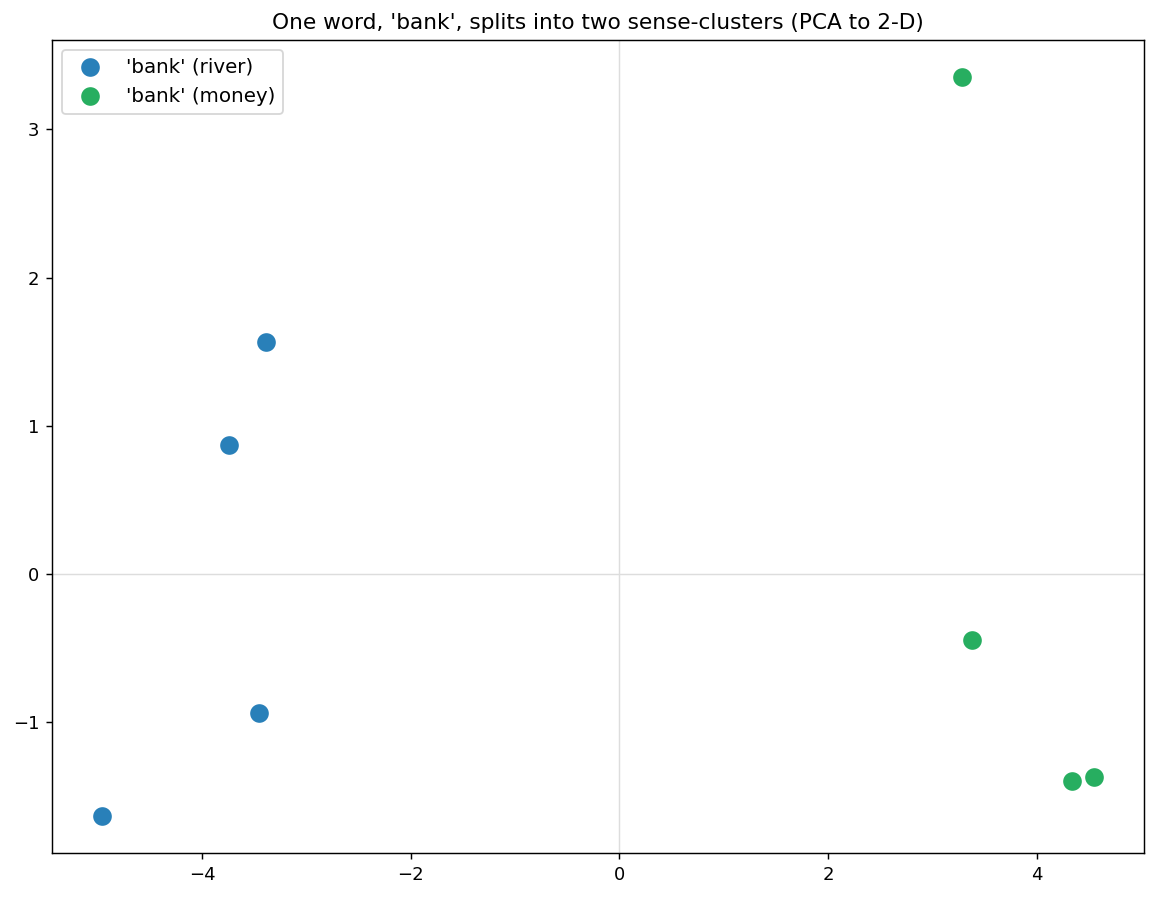

In [7]:
import matplotlib.pyplot as plt

def pca_2d(vectors):
    """Project (N, D) vectors to (N, 2) using PCA (via SVD)."""
    X = vectors - vectors.mean(axis=0)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    return X @ Vt[:2].T


# 'bank' in many sentences, tagged by sense
bank_data = [
    ("river", "I sat on the river bank in the sun."),
    ("river", "The boat drifted toward the muddy bank."),
    ("river", "Willow trees lined the far bank of the stream."),
    ("river", "We picnicked on the grassy bank by the lake."),
    ("money", "She works at a bank downtown."),
    ("money", "The bank approved my mortgage loan."),
    ("money", "I withdrew cash from the bank this morning."),
    ("money", "That bank charges high interest on credit."),
]

senses = [s for s, _ in bank_data]
vectors = np.stack([embed_word(sent, "bank") for _, sent in bank_data])
coords = pca_2d(vectors)

fig, ax = plt.subplots(figsize=(9, 7), dpi=130)
colors = {"river": "#2980b9", "money": "#27ae60"}
for sense in ["river", "money"]:
    pts = coords[[i for i, s in enumerate(senses) if s == sense]]
    ax.scatter(pts[:, 0], pts[:, 1], s=140, c=colors[sense], label=f"'bank' ({sense})",
               edgecolors="white", linewidths=1.5, zorder=3)
ax.set_title("One word, 'bank', splits into two sense-clusters (PCA to 2-D)")
ax.legend(fontsize=11)
ax.axhline(0, color="#ddd", lw=0.8); ax.axvline(0, color="#ddd", lw=0.8)
plt.tight_layout()
plt.show()

One word. Two clusters. A static embedding would have put **all eight dots on top of each
other** — a single point. The separation you see is meaning that only exists *because of
context*.

## 7. A caveat: contextual models learn our biases too

Like word2vec, DistilBERT learned from human text, so it absorbs human **stereotypes** —
and context can make them *sharper*. The cleanest way to see this is the task the model was
actually trained on: **fill in the blank**. We ask it to predict a masked word and read off
which it thinks is most likely.

This isn't a bug in the math — it's a faithful reflection of the training data, and it's
why practitioners audit and debias these models before deploying them.

In [8]:
from transformers import pipeline

filler = pipeline("fill-mask", model=MODEL_NAME)

def top_pronoun(sentence, k=2):
    preds = filler(sentence, top_k=k)
    return ", ".join(f"{p['token_str']} ({p['score']:.0%})" for p in preds)

print("The nurse said that [MASK] was tired.   ->", top_pronoun("The nurse said that [MASK] was tired."))
print("The engineer said that [MASK] was tired. ->", top_pronoun("The engineer said that [MASK] was tired."))
print("The doctor picked up [MASK] bag.         ->", top_pronoun("The doctor picked up [MASK] bag."))
print("The nurse picked up [MASK] bag.          ->", top_pronoun("The nurse picked up [MASK] bag."))

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

The nurse said that [MASK] was tired.   -> she (13%), he (5%)
The engineer said that [MASK] was tired. -> he (11%), she (3%)
The doctor picked up [MASK] bag.         -> the (39%), his (26%)
The nurse picked up [MASK] bag.          -> her (57%), the (20%)


Same sentence frame, different occupation, different predicted pronoun. The model is
reproducing associations from its training text — a reminder that "context-aware" doesn't
mean "unbiased."

## 8. Where this goes next

You've now watched a single word take on **different vectors in different sentences** —
the thing static embeddings couldn't do. But we've been treating the model as a **black
box**: sentence goes in, context-aware vectors come out. *How* does it decide that `bank`
should lean toward `water` in one sentence and `money` in another?

The mechanism is called **attention**: each word looks at the other words in the sentence
and pulls in the ones that are relevant. That's the box we open next — building attention
from scratch, the same way we built neurons and gradient descent from scratch earlier.

### Recap

| | word2vec (static) | DistilBERT (contextual) |
|---|---|---|
| unit | words | words (single-token here) |
| getting a vector | **lookup** a table row | **compute** from the whole sentence |
| vectors per word | exactly **one** | **one per context** |
| `bank` in two sentences | identical vector | different vectors |
| ambiguous words (`mouse`, `spring`) | collapse to one sense | keep their senses apart |
| tool kit | cosine, neighbors, PCA | **the same** |
| what's new | — | the vector is a **function of context** |